In [1]:
from mpasdiag import MPAS3DProcessor, SoundingDiagnostics, MPASSkewTPlotter


In [2]:
proc = MPAS3DProcessor(grid_file="../data/grids/x1.10242.static.nc", verbose=True)
proc.load_3d_data("../data/u240k/mpasout")

In [3]:
# 1. Extract the profile (nearest cell to the requested lon/lat)
diag = SoundingDiagnostics(verbose=True)
profile = diag.extract_sounding_profile(proc, lon=103.212, lat=3.772, time_index=0)

In [4]:
# 2. Compute indices (CAPE, CIN, SRH, bulk shear, …)
indices = diag.compute_thermodynamic_indices(
    profile["pressure"], profile["temperature"], profile["dewpoint"],
    u_wind_kt=profile.get("u_wind"), v_wind_kt=profile.get("v_wind"),
    height_m=profile.get("height"),
)

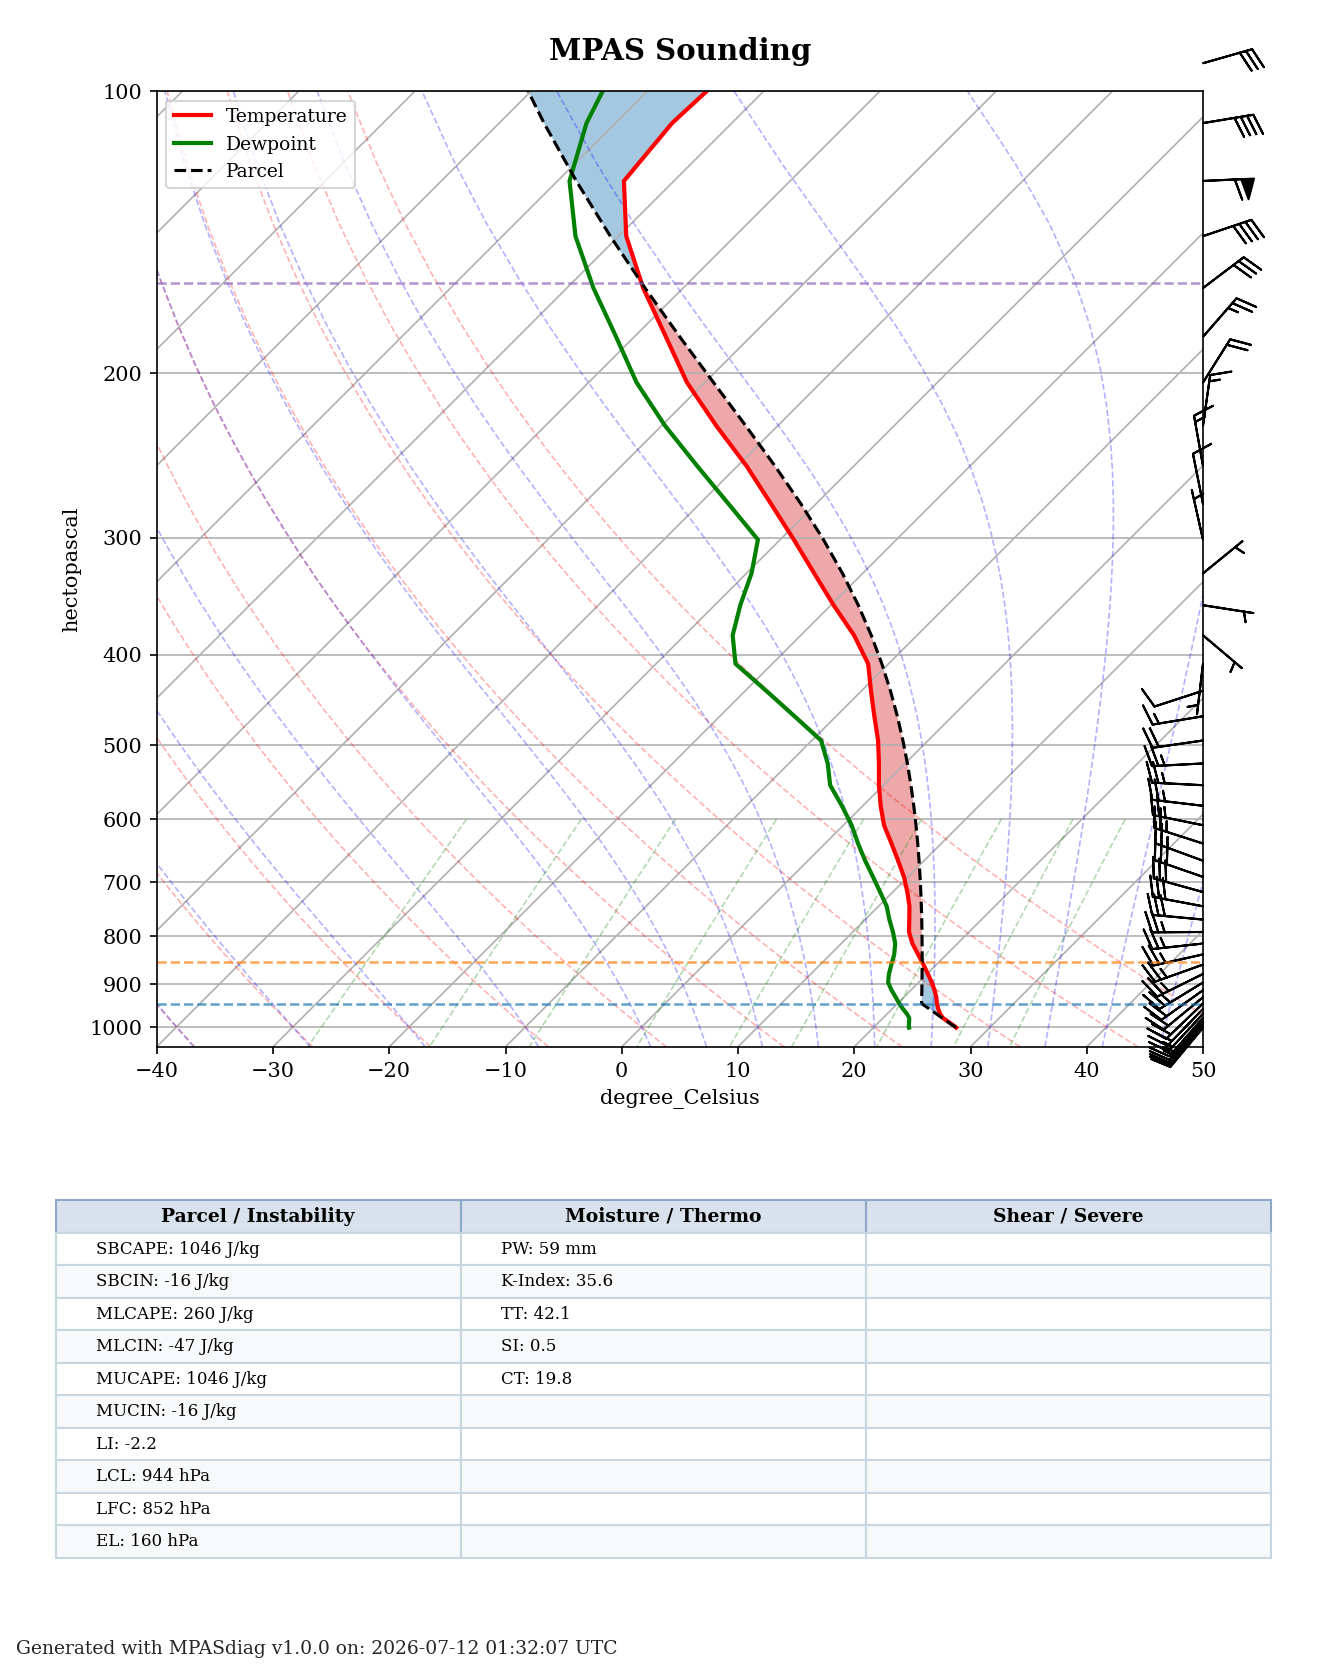

In [5]:
# 3. Draw the diagram with a lifted-parcel trace
plotter = MPASSkewTPlotter(figsize=(9, 12), dpi=150, verbose=True)
fig, ax = plotter.create_skewt_diagram(
    pressure=profile["pressure"], temperature=profile["temperature"],
    dewpoint=profile["dewpoint"],
    u_wind=profile.get("u_wind"), v_wind=profile.get("v_wind"),
    indices=indices, show_parcel=True, title="MPAS Sounding",
)

In [6]:
fig.savefig("./output/skewt.png", bbox_inches="tight", dpi=150)
